# EIT cooling rate, Be+

Rates in quanta/us. `n` is definite occupation, `nbar` the mean of a Poissonian.
The "SE" arrays are for the case  `eta_se = 0.1945`. Recombination is by
binning, detailed in `binning.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_ref  = np.load("data/reference_n.npy")
theory = np.load("data/rate_arr_theory_q35_061626.npy")/1e6      # stored in quanta/s
sim    = np.load("data/rates_arr_sim_072026.npy")/1e6

n_off, R_off = (np.load(f"data/noSE_{k}.npy") for k in ("n", "R"))
n_on,  R_on  = (np.load(f"data/SE_{k}.npy")   for k in ("n", "R"))

nb_off, P_off = (np.load(f"data/noSE_poisson_{k}.npy") for k in ("nbar", "R"))
nb_on,  P_on  = (np.load(f"data/SE_poisson_{k}.npy")   for k in ("nbar", "R"))

C_TH, C_SIM, C_OFF, C_SE = "#eb6834", "#1baf7a", "#2a78d6", "#c2317a"

def base(title, xlabel=r"occupation number  $n$", xmax=1.15e3):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    ax.plot(n_ref, theory, color=C_TH, lw=2, label="theory")
    ax.plot(n_ref, sim, color=C_SIM, lw=2, ls="--", dashes=(5, 3), label="simulation")
    ax.set_xscale("log"); ax.set_xlim(1, xmax); ax.set_ylim(-0.15, -0.045)
    ax.set_xlabel(xlabel); ax.set_ylabel(r"$dn/dt$   (quanta/$\mu$s)")
    ax.set_title(title); ax.grid(alpha=0.25, lw=0.6)
    return fig, ax

## 1. References

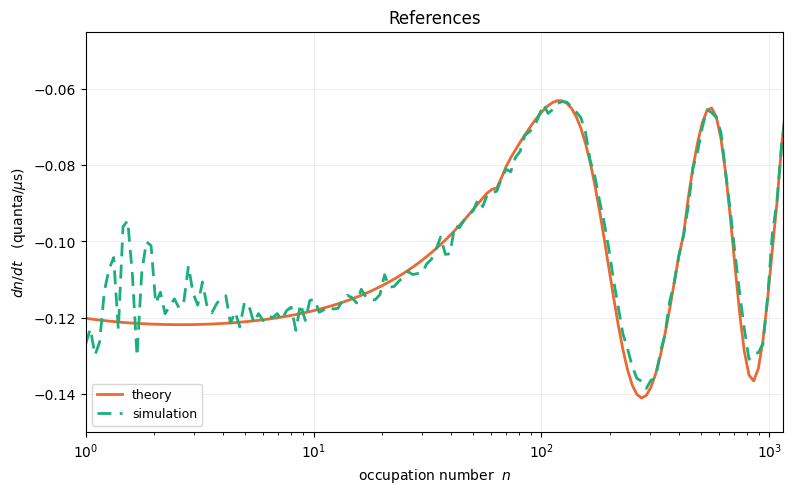

In [2]:
fig, ax = base("References")
ax.legend(loc="lower left", fontsize=9);

## 2. + no SE recoil

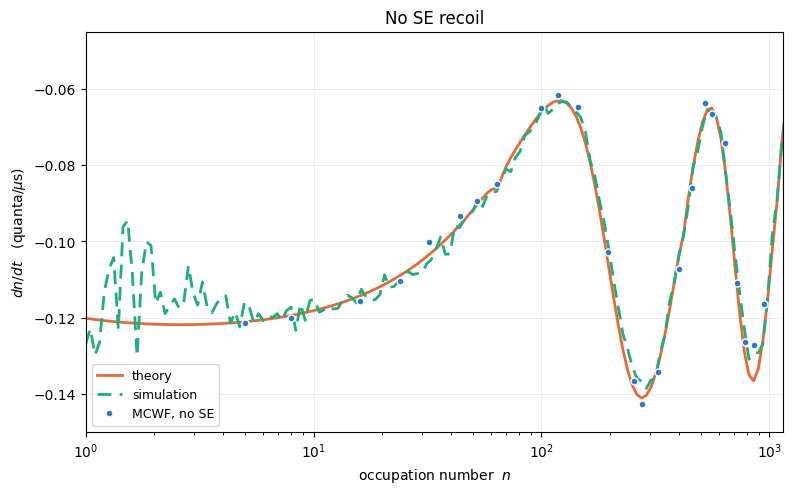

In [3]:
fig, ax = base("No SE recoil")
ax.plot(n_off, R_off, ls="none", marker="o", ms=5, mfc=C_OFF, mec="white",
        label="MCWF, no SE")
ax.legend(loc="lower left", fontsize=9);

## 3. + SE recoil

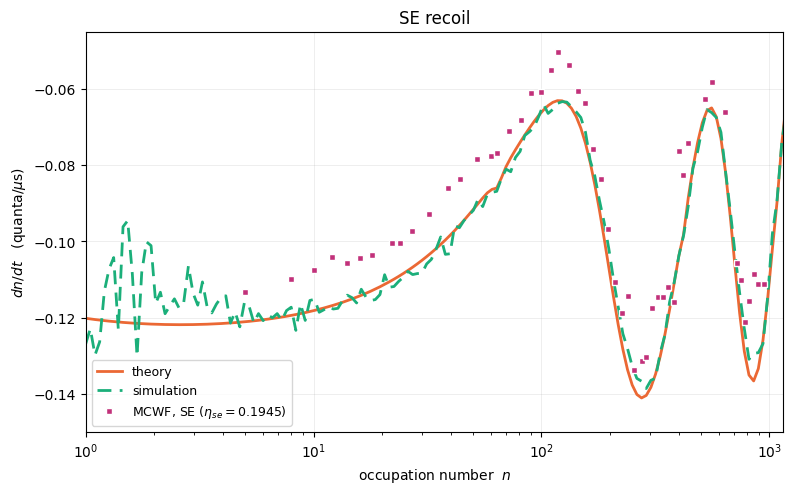

In [4]:
fig, ax = base("SE recoil")
ax.plot(n_on, R_on, ls="none", marker="s", ms=5, mfc=C_SE, mec="white",
        label=r"MCWF, SE ($\eta_{se}=0.1945$)")
ax.legend(loc="lower left", fontsize=9);

## 4. Both

The gap is the recoil heating term $\Gamma\eta_{\text{se}}^2$.

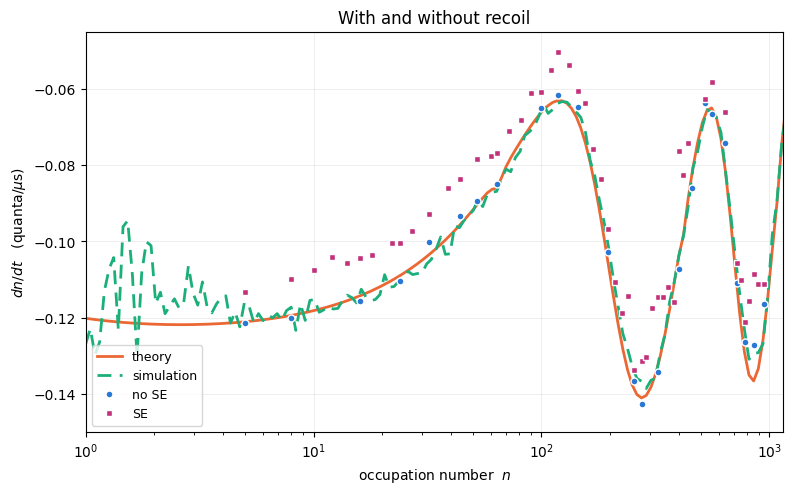

In [5]:
fig, ax = base("With and without recoil")
ax.plot(n_off, R_off, ls="none", marker="o", ms=5, mfc=C_OFF, mec="white", label="no SE")
ax.plot(n_on, R_on, ls="none", marker="s", ms=5, mfc=C_SE, mec="white", label="SE")
ax.legend(loc="lower left", fontsize=9);

## 5. Poisson-recombined (explained later)

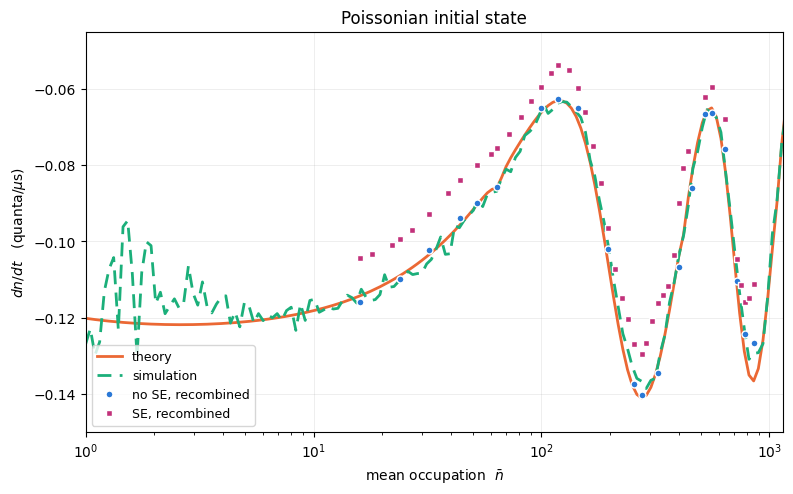

In [6]:
fig, ax = base("Poissonian initial state", r"mean occupation  $\bar n$")
ax.plot(nb_off, P_off, ls="none", marker="o", ms=5, mfc=C_OFF, mec="white",
        label="no SE, recombined")
ax.plot(nb_on, P_on, ls="none", marker="s", ms=5, mfc=C_SE, mec="white",
        label="SE, recombined")
ax.legend(loc="lower left", fontsize=9);

## 6. Definite $n$ vs Poissonian $\bar n$, same data


Note that the shortest $\bar{n}$ for which we can reliably compute rates using this method is limited by our datapoints which start at $n=5$; we introduce a "$\text{tol}$" parameter that ensures recombination only at points where the support $n \in [5, 950]$ can account for $\geq 1- \text{tol}$ of the poisson distribution weight. 

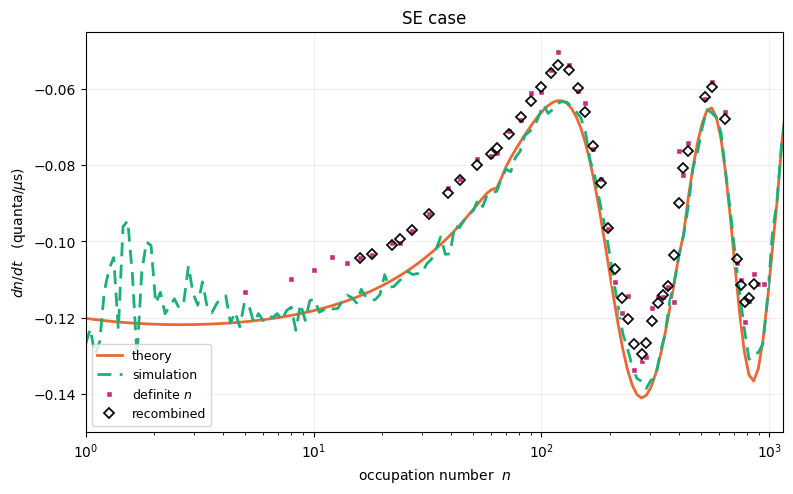

In [7]:
fig, ax = base("SE case")
ax.plot(n_on, R_on, ls="none", marker="s", ms=5, mfc=C_SE, mec="white",
        label=r"definite $n$")
ax.plot(nb_on, P_on, ls="none", marker="D", ms=5, mfc="none", mec="#0b0b0b",
        mew=1.3, label="recombined")
ax.legend(loc="lower left", fontsize=9);

## 7. What the binning actually does

The Poisson kernel is defined on every integer `k`. Each `k` is assigned to the
nearest measured `n_j`, and the probability inside each cell is summed to give
that point's weight.

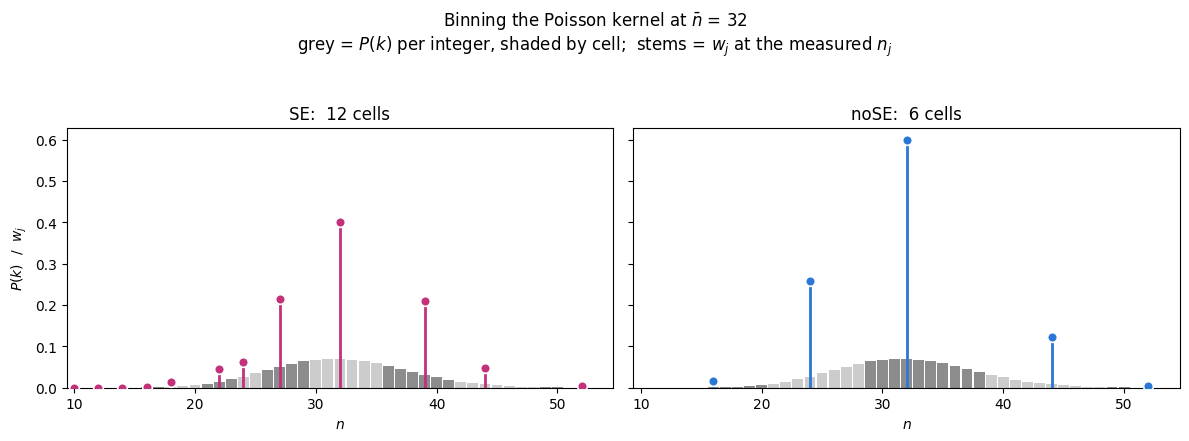

In [8]:
from binning import poisson_kernel, weights

NBAR = 32.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

for ax, (tag, n, c) in zip(axes, (("SE", n_on, C_SE), ("noSE", n_off, C_OFF))):
    k, p = poisson_kernel(NBAR)
    j = np.abs(np.clip(k, n[0], n[-1])[:, None] - n[None, :]).argmin(1)
    w, _ = weights(n, NBAR)
    lo, hi = NBAR - 4*np.sqrt(NBAR), NBAR + 4*np.sqrt(NBAR)
    vis = (k >= lo) & (k <= hi)

    # P(k): one bar per integer, shaded alternately by the cell it fell into
    for m, i in enumerate(np.unique(j[vis])):
        s = vis & (j == i)
        ax.bar(k[s], p[s], width=0.9, color="0.55" if m % 2 else "0.80",
               edgecolor="none", zorder=1)

    # w_j: the summed probability, drawn at the measured point that owns it
    used = np.unique(j[vis])
    ax.vlines(n[used], 0, w[used], color=c, lw=2, zorder=2)
    ax.plot(n[used], w[used], ls="none", marker="o", ms=7, mfc=c, mec="white",
            mew=1.2, zorder=3)

    ax.set_xlim(lo, hi)
    ax.set_xlabel(r"$n$")
    ax.set_title(f"{tag}:  {len(used)} cells")

axes[0].set_ylabel(r"$P(k)$  /  $w_j$")
fig.suptitle(rf"Binning the Poisson kernel at $\bar n$ = {NBAR:.0f}"
             "\ngrey = $P(k)$ per integer, shaded by cell;  "
             "stems = $w_j$ at the measured $n_j$", y=1.04)
fig.tight_layout();

## 8. Does binning recover the right answer?

The theory curve is sampled densely enough to act as a known `R(n)`, so the exact
`sum_k P(k) R(k)` can be computed. To validate our "binning" method, we subsample that same curve at our measured `n`,
bin it, and compare - this can be thought of as reflecting our method's discretisation error.

SE    rms(binned - truth) 0.00047   worst 0.00221
noSE  rms(binned - truth) 0.00079   worst 0.00251


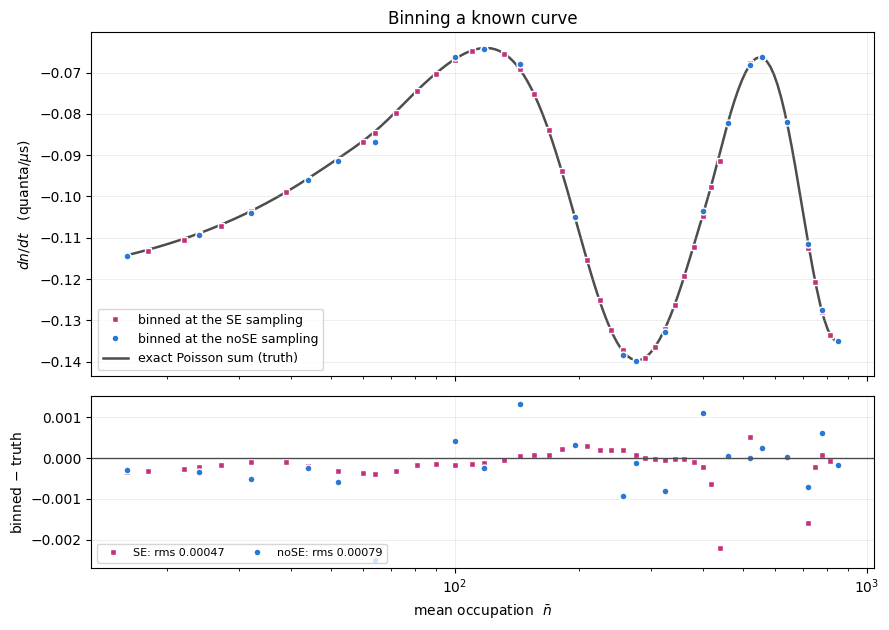

In [9]:
from binning import recombine, poisson_kernel

def truth(nbar):                      # exact sum over integers, using dense R(n)
    k, p = poisson_kernel(nbar)
    return p @ np.interp(np.log(np.clip(k, n_ref[0], n_ref[-1])),
                         np.log(n_ref), theory)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6.4), sharex=True,
                             gridspec_kw=dict(height_ratios=[2, 1]))

for tag, ns, c in (("SE", n_on, C_SE), ("noSE", n_off, C_OFF)):
    R_sub = np.interp(np.log(ns), np.log(n_ref), theory)   # theory at our n only
    nbar, v = recombine(ns, R_sub)
    t = np.array([truth(b) for b in nbar])
    d = v - t
    a1.plot(nbar, v, ls="none", marker="o" if tag == "noSE" else "s", ms=5,
            mfc=c, mec="white", label=f"binned at the {tag} sampling")
    a2.plot(nbar, d, ls="none", marker="o" if tag == "noSE" else "s", ms=5,
            mfc=c, mec="white", label=f"{tag}: rms {np.sqrt((d**2).mean()):.5f}")
    print(f"{tag:5s} rms(binned - truth) {np.sqrt((d**2).mean()):.5f}"
          f"   worst {np.max(np.abs(d)):.5f}")

nb_fine = np.logspace(np.log10(16), np.log10(854), 200)
a1.plot(nb_fine, [truth(b) for b in nb_fine], color="0.3", lw=1.8, zorder=0,
        label="exact Poisson sum (truth)")
a1.set_xscale("log"); a1.set_ylabel(r"$dn/dt$   (quanta/$\mu$s)")
a1.set_title("Binning a known curve"); a1.grid(alpha=0.25, lw=0.6)
a1.legend(loc="lower left", fontsize=9)

a2.axhline(0, color="0.3", lw=1)
a2.set_xlabel(r"mean occupation  $\bar n$")
a2.set_ylabel("binned $-$ truth"); a2.grid(alpha=0.25, lw=0.6)
a2.legend(loc="lower left", fontsize=8, ncol=2)
fig.tight_layout();